In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

import os
os.makedirs("../results/04", exist_ok = True)

In [3]:
df = pd.read_csv("../data/processed/tpd_2018_2025.csv", low_memory = False)
df.head()

,IncidentID,Year,Month,Day,Hour,Division,Ward,UCR,UCRDescription,Offense,CallSource
0,112318516Z,2022,January,Sat,0,West,0,6,06 - LARCENY,603,Web Reported
1,009240162Z,2022,March,Tue,13,West,1,2,02 - SEXUAL ASSAULT,203,Unknown
2,1210180043,2019,February,Tue,3,South,5,1,01 - HOMICIDE,101,Unknown
3,1801010290,2018,January,Mon,10,West,1,7,07 - GTA,701,Call For Service
4,1801010146,2018,January,Mon,4,South,5,4,"04 - ASSAULT, AGGRAVATED",403,Call For Service


In [4]:
# drop columns not used
df = df.drop(columns = ["IncidentID", "UCR", "Offense"])

# one-hot encode
df_encoded = pd.get_dummies(df, columns = ["Division", "CallSource", "Ward", "Month", "Day"], drop_first = True)

# using same selected features from classification
selected_features = ['Hour', 'Year', 'CallSource_Web Reported', 'CallSource_Officer-Initiated', 
                     'Day_Mon', 'Day_Thu', 'Day_Wed', 'Day_Tue', 'Day_Sat', 'Day_Sun', 
                     'Month_May', 'Month_March', 'Month_October', 'Month_January', 
                     'Month_February', 'Month_July', 'Month_August', 'Month_June', 
                     'Month_September', 'Month_November', 'Month_December', 'Division_Midtown']

X = df_encoded[selected_features]

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(243127, 22)

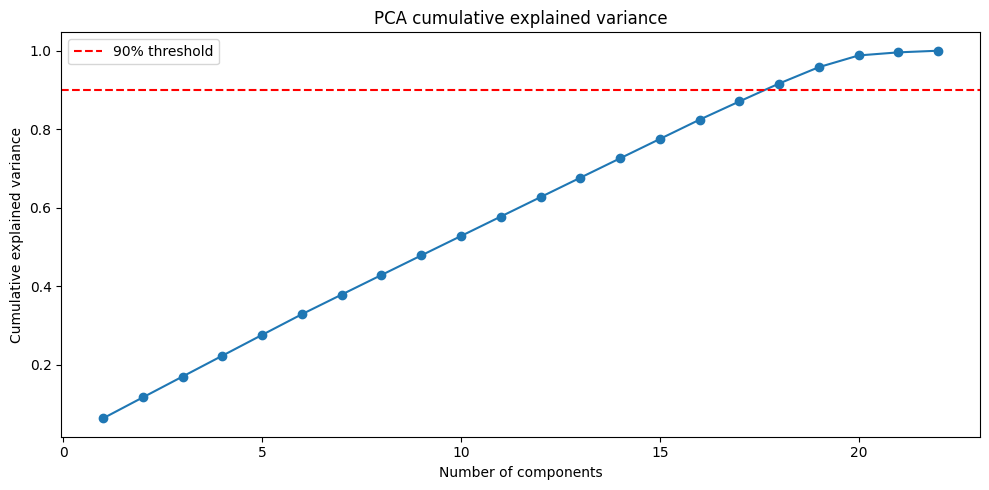

In [5]:
# Principal Component Analysis (PCA)

pca = PCA(random_state = 42)
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize = (10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker = "o")
plt.axhline(y = 0.90, color = "r", linestyle = "--", label = "90% threshold")
plt.title("PCA cumulative explained variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.savefig("../results/04/pca_explained_variance.png", dpi = 150, bbox_inches = "tight")
plt.show()

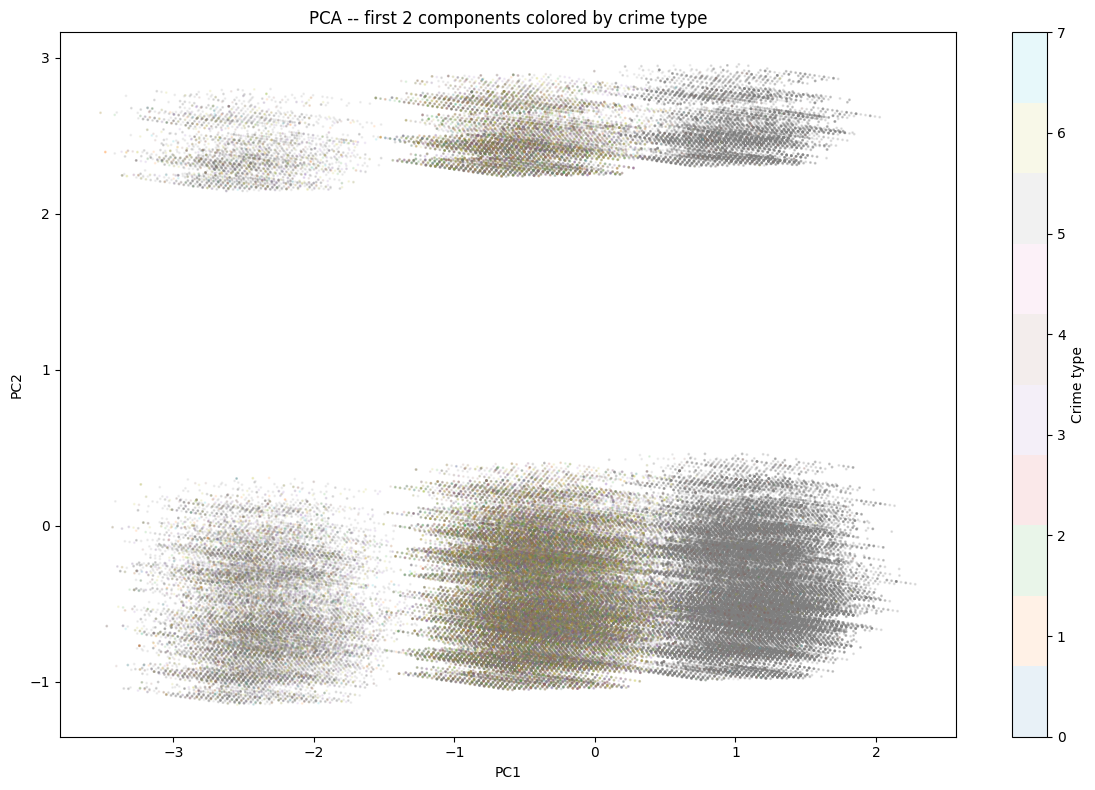

In [6]:
# 1st 2 PCs

pca_2d = PCA(n_components = 2, random_state = 42)
X_pca = pca_2d.fit_transform(X_scaled)
le = LabelEncoder()
y_encoded = le.fit_transform(df["UCRDescription"])

plt.figure(figsize = (12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c = y_encoded, cmap = "tab10", alpha = 0.1, s = 1)
plt.colorbar(scatter, label = "Crime type")
plt.title("PCA -- first 2 components colored by crime type")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("../results/04/pca_2d.png", dpi = 150, bbox_inches = "tight")
plt.show()

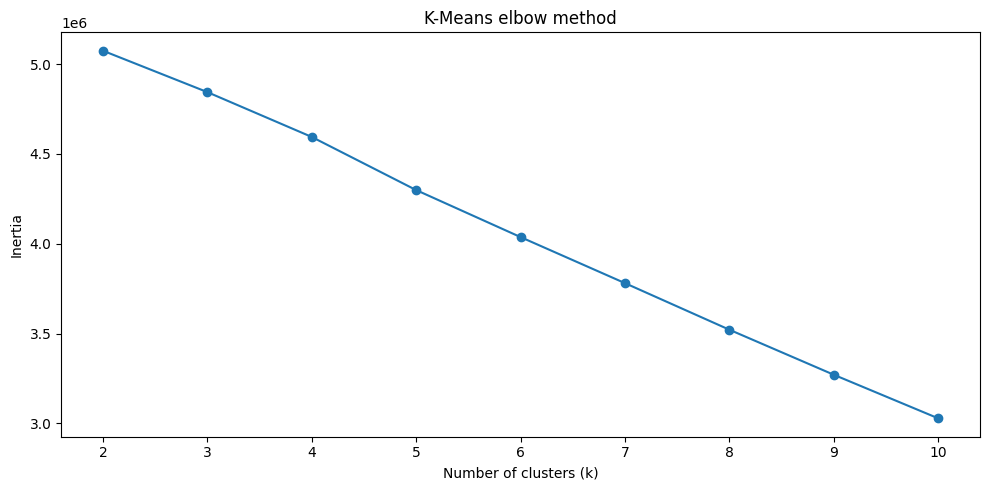

In [7]:
# K-means clustering - elbow method

inertias = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize = (10, 5))
plt.plot(k_range, inertias, marker = "o")
plt.title("K-Means elbow method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("../results/04/kmeans_elbow.png", dpi = 150, bbox_inches = "tight")
plt.show()

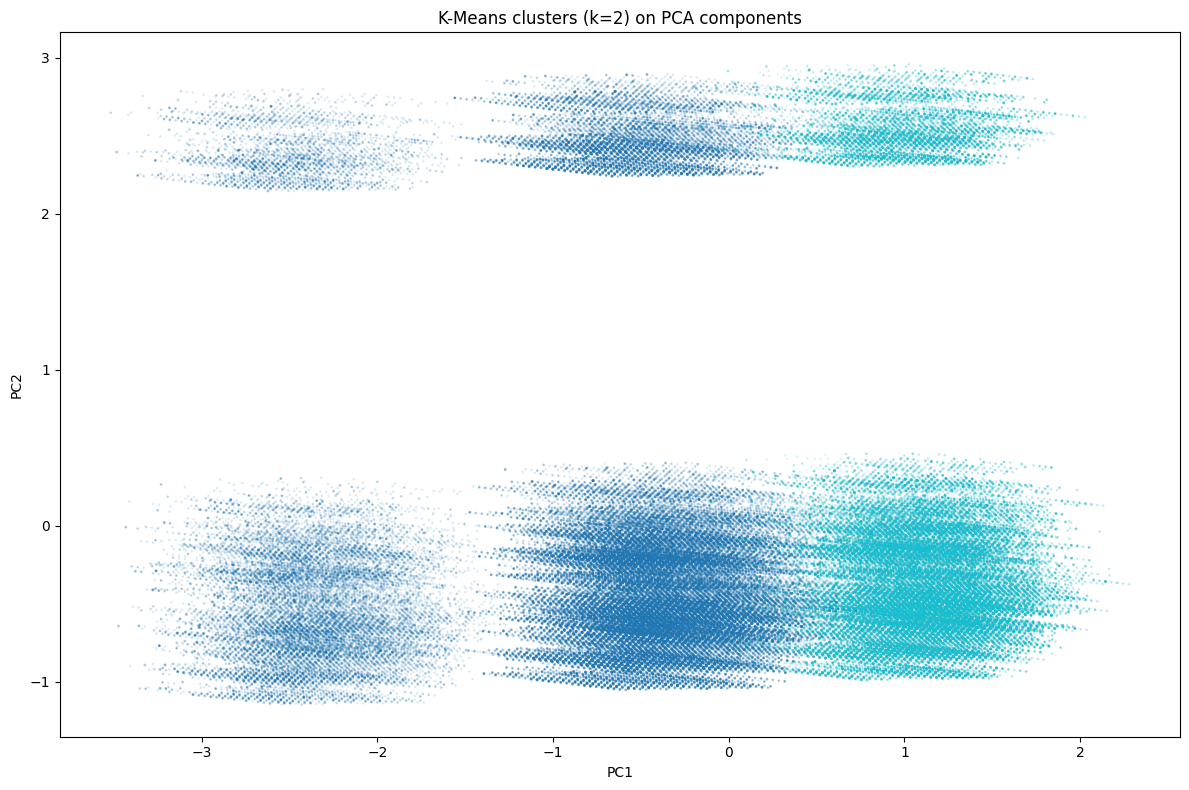

In [8]:
# k-means clustering with k = 2

kmeans = KMeans(n_clusters = 2, random_state = 42, n_init = 10)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize = (12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = clusters, cmap = "tab10", alpha = 0.1, s = 1)
plt.title("K-Means clusters (k=2) on PCA components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("../results/04/kmeans_clusters.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [9]:
df_encoded["cluster"] = clusters

print("Cluster sizes:")
print(df_encoded["cluster"].value_counts())

print("\nMean Hour by cluster:")
print(df_encoded.groupby("cluster")["Hour"].mean())

print("\nMean Year by cluster:")
print(df_encoded.groupby("cluster")["Year"].mean())

Cluster sizes:
cluster
0    137730
1    105397
Name: count, dtype: int64

Mean Hour by cluster:
cluster
0    12.558622
1    14.024583
Name: Hour, dtype: float64

Mean Year by cluster:
cluster
0    2021.311385
1    2021.745135
Name: Year, dtype: float64


<Figure size 1200x500 with 0 Axes>

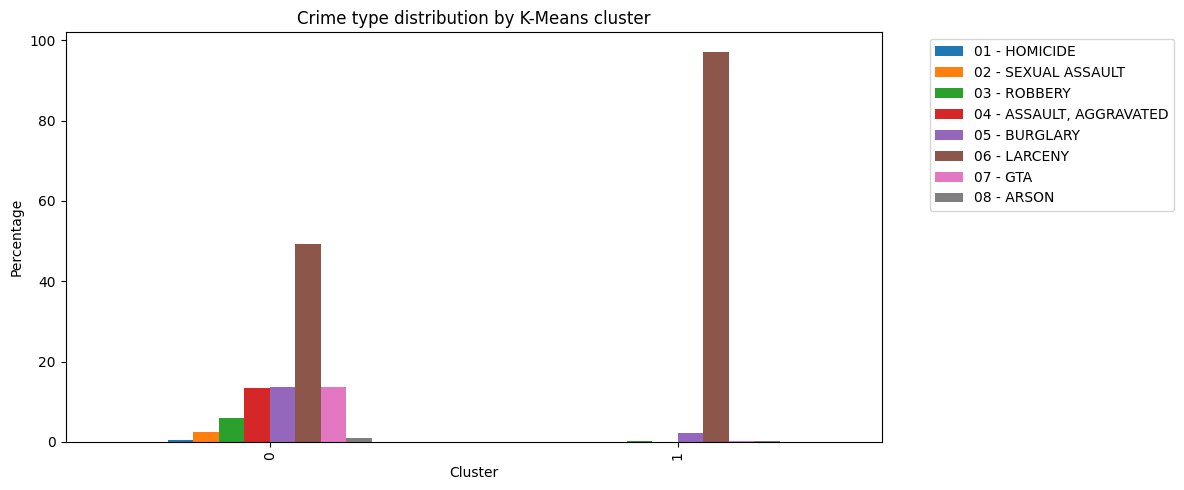

In [10]:
cluster_crime = df_encoded.groupby(["cluster", df["UCRDescription"]]).size().unstack(fill_value = 0)
cluster_crime_pct = cluster_crime.div(cluster_crime.sum(axis = 1), axis = 0) * 100

plt.figure(figsize = (12, 5))
cluster_crime_pct.plot(kind = "bar", figsize = (12, 5))
plt.title("Crime type distribution by K-Means cluster")
plt.xlabel("Cluster")
plt.ylabel("Percentage")
plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left")
plt.tight_layout()
plt.savefig("../results/04/kmeans_crime_distribution.png", dpi = 150, bbox_inches = "tight")
plt.show()

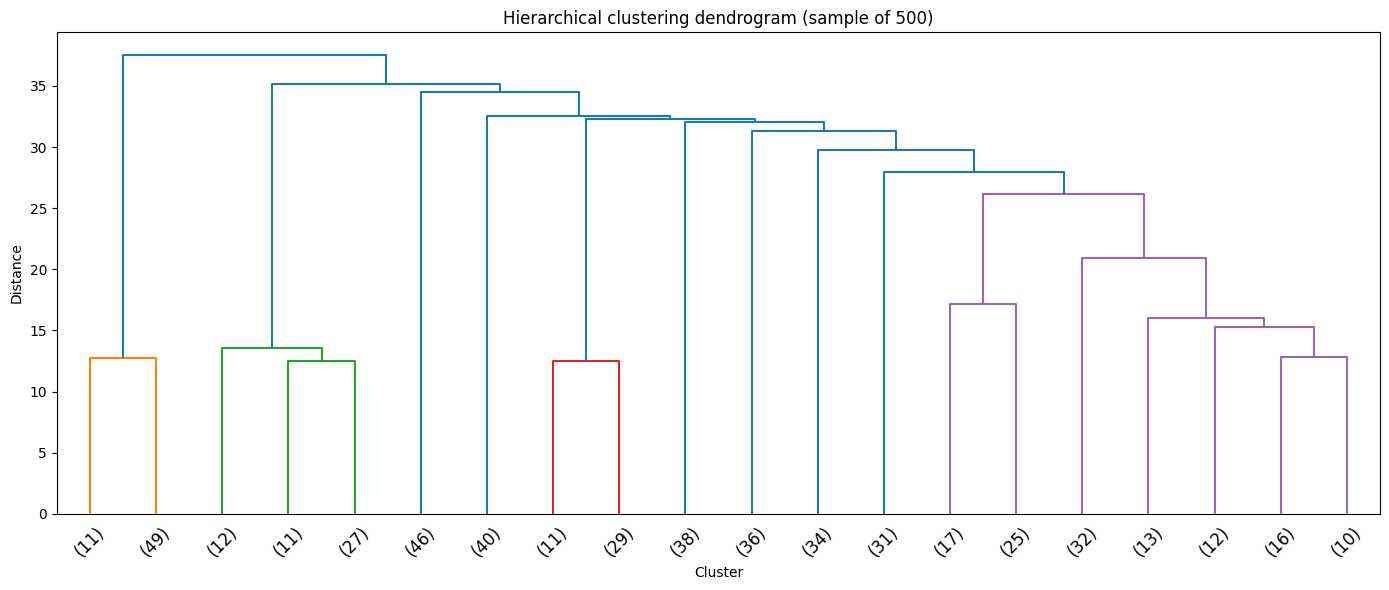

In [ ]:
# sample 500 rows for hierarchical clustering
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 500, replace = False)
X_sample = X_scaled[sample_idx]

# fit linkage
Z = linkage(X_sample, method = "ward")

plt.figure(figsize = (14, 6))
dendrogram(Z, truncate_mode = "lastp", p = 20, leaf_rotation = 45)
plt.title("Hierarchical clustering dendrogram (sample of 500)")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("../results/04/hierarchical_dendrogram.png", dpi = 150, bbox_inches = "tight")
plt.show()